# Exploring Myoglobin Mutations with DSI and RCSB PDB

## User Story

**As a structural biology researcher, I want to retrieve and compare related
myoglobin structures from the Protein Data Bank so that I can examine how
selected amino-acid substitutions relate to differences in protein structure.**

This notebook demonstrates a complete scientific workflow using the DSI
RCSBPDB backend:

**Scientific question → PDB structure retrieval → normalized DSI metadata →
structural resources → structure analysis → visualization**

### Scientific Question

How similar are the three-dimensional structures of selected recombinant sperm
whale myoglobin mutants?

For this demonstration, four related PDB structures are examined:

| PDB ID | Mutation |
|---|---|
| 1CH1 | L89G |
| 1CH2 | L89F |
| 1CH3 | L89W |
| 1CH5 | H97V |

The purpose is not to establish the biological consequences of these mutations,
but to demonstrate how DSI can connect repository data discovery and access to
a downstream structural-analysis workflow.

As a first choice, I chose the myoglobin mutant example because the dataset contains a compact group of closely related structures representing mutations of the same protein. That gives a controlled comparison: instead of comparing unrelated proteins, the demo looks at variants of one protein and asks whether their overall structures remain similar.

### Overall Story

In this user story, I selected four related sperm whale myoglobin mutant structures from PDB and used the DSI RCSBPDB backend to retrieve their metadata and available structure files in one workflow. From the DSI datasets table, I look at the basic information for each structure, and from the resources table, I identify and download the corresponding mmCIF coordinate files. Once the structural files are available, I use BioPython to parse them and compare the proteins. I first summarize basic properties such as chains, residues, atoms, and the presence of the heme group. Then I align corresponding C-alpha atoms between the structures and calculate RMSD values to quantify how similar or different their overall 3D structures are. Finally, I visualize those comparisons using an RMSD bar chart, a pairwise RMSD heatmap, and interactive 3D molecular views with py3Dmol. So overall, the demo shows the complete path from retrieving related PDB structures through DSI to performing a small structural comparison and visualizing the result.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from dsi.dsi import DSI

print("Python environment:", sys.executable)

Python environment: /Users/rsankararaman/PDB_new/venv/bin/python


## 1. Select Related Myoglobin Structures

The PDB contains multiple experimentally determined structures of recombinant
sperm whale myoglobin with substitutions at specific amino-acid positions.

A small set of four structures is used here so that the workflow remains
reproducible and easy to interpret.

In [2]:
# Defines the four selected myoglobin PDB structures and their corresponding mutations for this user story.

selected_structures = pd.DataFrame(
    {
        "pdb_id": ["1CH1", "1CH2", "1CH3", "1CH5"],
        "mutation": ["L89G", "L89F", "L89W", "H97V"],
    }
)

selected_structures

,pdb_id,mutation
0,1CH1,L89G
1,1CH2,L89F
2,1CH3,L89W
3,1CH5,H97V


## 2. Retrieve the Structures Through DSI

The DSI RCSBPDB backend provides read-only programmatic access to RCSB PDB
metadata and downloadable structure resources.

Rather than accessing each PDB record manually, the four PDB identifiers are
provided together to a single DSI backend instance.

In [3]:
# Creates a DSI RCSBPDB backend instance to retrieve all four selected PDB entries in one request.

pdb_ids = selected_structures["pdb_id"].tolist()

dsi = DSI(
    backend_name="RCSBPDB",
    params={
        "pdb_id": pdb_ids
    }
)

Created an instance of DSI with the RCSBPDB read-only backend


In [4]:
dsi.list()


Table: datasets
  - num of columns: 12
  - num of rows: 4

Table: resources
  - num of columns: 8
  - num of rows: 40

Table: errors
  - num of columns: 7
  - num of rows: 0




### DSI's normalized representation

The RCSBPDB backend represents repository information using three tables:

- **datasets** — one row describing each resolved PDB structure.
- **resources** — downloadable files associated with the structures.
- **errors** — identifiers that could not be resolved or processed.

For successful lookups, the `datasets` and `resources` tables form the bridge
between repository metadata and the actual structural files used downstream.

In [5]:
# Retrieves the full normalized DSI datasets table containing metadata for the selected PDB structures.

datasets = dsi.get_table(
    "datasets",
    collection=True
)

datasets

Storing all data for the table: datasets as a collection


,dataset_id,doi,title,description,landing_page,metadata_url,experimental_method,release_date,revision_date,resource_count,raw_metadata,notes
0,1CH1,10.2210/pdb1ch1/pdb,Recombinant sperm whale myoglobin L89G mutatnt...,"OXYGEN STORAGE/TRANSPORT: OXYGEN TRANSPORT, HE...",https://www.rcsb.org/structure/1CH1,https://data.rcsb.org/rest/v1/core/entry/1CH1,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,2026-08-12T00:00:00.000+00:00,10,"{""citation"": [{""country"": ""US"", ""id"": ""primary...",None
1,1CH2,10.2210/pdb1ch2/pdb,RECOMBINANT SPERM WHALE MYOGLOBIN L89F MUTANT ...,"OXYGEN STORAGE/TRANSPORT: OXYGEN TRANSPORT, HE...",https://www.rcsb.org/structure/1CH2,https://data.rcsb.org/rest/v1/core/entry/1CH2,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,2026-08-12T00:00:00.000+00:00,10,"{""citation"": [{""country"": ""US"", ""id"": ""primary...",None
2,1CH3,10.2210/pdb1ch3/pdb,RECOMBINANT SPERM WHALE MYOGLOBIN L89W MUTANT ...,"OXYGEN STORAGE/TRANSPORT: OXYGEN TRANSPORT, HE...",https://www.rcsb.org/structure/1CH3,https://data.rcsb.org/rest/v1/core/entry/1CH3,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,2026-08-12T00:00:00.000+00:00,10,"{""citation"": [{""country"": ""US"", ""id"": ""primary...",None
3,1CH5,10.2210/pdb1ch5/pdb,RECOMBINANT SPERM WHALE MYOGLOBIN H97V MUTANT ...,"OXYGEN STORAGE/TRANSPORT: OXYGEN TRANSPORT, HE...",https://www.rcsb.org/structure/1CH5,https://data.rcsb.org/rest/v1/core/entry/1CH5,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,2026-08-12T00:00:00.000+00:00,10,"{""citation"": [{""country"": ""US"", ""id"": ""primary...",None


In [6]:
# Selects the most relevant PDB metadata fields to create a cleaner dataset summary for the demo.

dataset_view = datasets[
    [
        "dataset_id",
        "doi",
        "title",
        "experimental_method",
        "release_date",
        "resource_count",
    ]
].copy()

dataset_view

,dataset_id,doi,title,experimental_method,release_date,resource_count
0,1CH1,10.2210/pdb1ch1/pdb,Recombinant sperm whale myoglobin L89G mutatnt...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10
1,1CH2,10.2210/pdb1ch2/pdb,RECOMBINANT SPERM WHALE MYOGLOBIN L89F MUTANT ...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10
2,1CH3,10.2210/pdb1ch3/pdb,RECOMBINANT SPERM WHALE MYOGLOBIN L89W MUTANT ...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10
3,1CH5,10.2210/pdb1ch5/pdb,RECOMBINANT SPERM WHALE MYOGLOBIN H97V MUTANT ...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10


In [7]:
# Adds the known mutation labels to the retrieved PDB metadata so each structure can be connected to its variant.

dataset_view = dataset_view.merge(
    selected_structures,
    left_on="dataset_id",
    right_on="pdb_id",
    how="left"
)

dataset_view = dataset_view[
    [
        "dataset_id",
        "mutation",
        "title",
        "experimental_method",
        "release_date",
        "resource_count",
    ]
]

dataset_view

,dataset_id,mutation,title,experimental_method,release_date,resource_count
0,1CH1,L89G,Recombinant sperm whale myoglobin L89G mutatnt...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10
1,1CH2,L89F,RECOMBINANT SPERM WHALE MYOGLOBIN L89F MUTANT ...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10
2,1CH3,L89W,RECOMBINANT SPERM WHALE MYOGLOBIN L89W MUTANT ...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10
3,1CH5,H97V,RECOMBINANT SPERM WHALE MYOGLOBIN H97V MUTANT ...,X-RAY DIFFRACTION,1999-04-09T00:00:00.000+00:00,10


## 3. Identify Downloadable Structural Resources

Repository metadata describes the structures, but structural analysis requires the coordinate files themselves.

The RCSBPDB backend exposes these files through the DSI `resources` table,
allowing the scientific workflow to move from metadata to downloadable data.

In [8]:
# Retrieves the DSI resources table containing the downloadable files associated with each PDB structure.
resources = dsi.get_table(
    "resources",
    collection=True
)

resources

Storing all data for the table: resources as a collection


,resource_id,dataset_id,name,download_url,format,resource_type,source,raw_metadata
0,1CH1:1,1CH1,1ch1.cif,https://files.rcsb.org/download/1CH1.cif,cif,PDBx/mmCIF Format,rcsb.download,"{""content_type"": ""chemical/x-cif"", ""exists"": t..."
1,1CH1:2,1CH1,1ch1.cif.gz,https://files.rcsb.org/download/1CH1.cif.gz,cif.gz,PDBx/mmCIF Format (gz),rcsb.download,"{""content_type"": ""application/gzip"", ""exists"":..."
2,1CH1:3,1CH1,1ch1.pdb,https://files.rcsb.org/download/1CH1.pdb,pdb,Legacy PDB Format,rcsb.download,"{""content_type"": ""text/plain"", ""exists"": true,..."
3,1CH1:4,1CH1,1ch1.pdb.gz,https://files.rcsb.org/download/1CH1.pdb.gz,pdb.gz,Legacy PDB Format (gz),rcsb.download,"{""content_type"": ""application/gzip"", ""exists"":..."
4,1CH1:5,1CH1,1ch1.xml.gz,https://files.rcsb.org/download/1CH1.xml.gz,xml.gz,PDBML/XML Format (gz),rcsb.download,"{""content_type"": ""application/gzip"", ""exists"":..."
5,1CH1:6,1CH1,1ch1-sf.cif,https://files.rcsb.org/download/1CH1-sf.cif,cif,Structure Factors (CIF),rcsb.download,"{""content_type"": ""chemical/x-cif"", ""exists"": t..."
6,1CH1:7,1CH1,1ch1-sf.cif.gz,https://files.rcsb.org/download/1CH1-sf.cif.gz,cif.gz,Structure Factors (CIF - gz),rcsb.download,"{""content_type"": ""application/gzip"", ""exists"":..."
7,1CH1:8,1CH1,1ch1_validation.pdf.gz,https://files.rcsb.org/pub/pdb/validation_repo...,pdf.gz,Validation Full (PDF - gz),rcsb.validation,"{""content_type"": ""application/gzip"", ""exists"":..."
8,1CH1:9,1CH1,1ch1_validation.xml.gz,https://files.rcsb.org/pub/pdb/validation_repo...,xml.gz,Validation (XML - gz),rcsb.validation,"{""content_type"": ""application/gzip"", ""exists"":..."
9,1CH1:10,1CH1,1ch1_validation.cif.gz,https://files.rcsb.org/pub/pdb/validation_repo...,cif.gz,Validation (CIF - gz),rcsb.validation,"{""content_type"": ""application/gzip"", ""exists"":..."


In [9]:
# Creates a simplified view of the available PDB resources, including file type and download URL.

resource_view = resources[
    [
        "dataset_id",
        "name",
        "format",
        "resource_type",
        "download_url",
    ]
].copy()

resource_view

,dataset_id,name,format,resource_type,download_url
0,1CH1,1ch1.cif,cif,PDBx/mmCIF Format,https://files.rcsb.org/download/1CH1.cif
1,1CH1,1ch1.cif.gz,cif.gz,PDBx/mmCIF Format (gz),https://files.rcsb.org/download/1CH1.cif.gz
2,1CH1,1ch1.pdb,pdb,Legacy PDB Format,https://files.rcsb.org/download/1CH1.pdb
3,1CH1,1ch1.pdb.gz,pdb.gz,Legacy PDB Format (gz),https://files.rcsb.org/download/1CH1.pdb.gz
4,1CH1,1ch1.xml.gz,xml.gz,PDBML/XML Format (gz),https://files.rcsb.org/download/1CH1.xml.gz
5,1CH1,1ch1-sf.cif,cif,Structure Factors (CIF),https://files.rcsb.org/download/1CH1-sf.cif
6,1CH1,1ch1-sf.cif.gz,cif.gz,Structure Factors (CIF - gz),https://files.rcsb.org/download/1CH1-sf.cif.gz
7,1CH1,1ch1_validation.pdf.gz,pdf.gz,Validation Full (PDF - gz),https://files.rcsb.org/pub/pdb/validation_repo...
8,1CH1,1ch1_validation.xml.gz,xml.gz,Validation (XML - gz),https://files.rcsb.org/pub/pdb/validation_repo...
9,1CH1,1ch1_validation.cif.gz,cif.gz,Validation (CIF - gz),https://files.rcsb.org/pub/pdb/validation_repo...


In [10]:
errors = dsi.get_table(
    "errors",
    collection=True
)

errors

,identifier,normalized_identifier,repo,status,endpoint_used,endpoint_variables,notes


In [11]:
if errors.empty:
    print("All selected PDB identifiers were resolved successfully.")
else:
    print("Some identifiers could not be resolved:")
    display(errors)

All selected PDB identifiers were resolved successfully.


In [12]:
%pip install biopython py3Dmol

Note: you may need to restart the kernel to use updated packages.


In [13]:
import requests

from Bio.PDB import MMCIFParser
from Bio.PDB import Superimposer

import py3Dmol

In [14]:
resources["format"].value_counts(dropna=False)

format
cif.gz    12
cif        8
xml.gz     8
pdb        4
pdb.gz     4
pdf.gz     4
Name: count, dtype: int64

In [15]:
# Displays the structure IDs, filenames, formats, and download URLs available through the DSI resources table.

resources[
    ["dataset_id", "name", "format", "download_url"]
]

,dataset_id,name,format,download_url
0,1CH1,1ch1.cif,cif,https://files.rcsb.org/download/1CH1.cif
1,1CH1,1ch1.cif.gz,cif.gz,https://files.rcsb.org/download/1CH1.cif.gz
2,1CH1,1ch1.pdb,pdb,https://files.rcsb.org/download/1CH1.pdb
3,1CH1,1ch1.pdb.gz,pdb.gz,https://files.rcsb.org/download/1CH1.pdb.gz
4,1CH1,1ch1.xml.gz,xml.gz,https://files.rcsb.org/download/1CH1.xml.gz
5,1CH1,1ch1-sf.cif,cif,https://files.rcsb.org/download/1CH1-sf.cif
6,1CH1,1ch1-sf.cif.gz,cif.gz,https://files.rcsb.org/download/1CH1-sf.cif.gz
7,1CH1,1ch1_validation.pdf.gz,pdf.gz,https://files.rcsb.org/pub/pdb/validation_repo...
8,1CH1,1ch1_validation.xml.gz,xml.gz,https://files.rcsb.org/pub/pdb/validation_repo...
9,1CH1,1ch1_validation.cif.gz,cif.gz,https://files.rcsb.org/pub/pdb/validation_repo...


In [16]:
# Filters the retrieved resources to keep only CIF/mmCIF coordinate files for structural analysis.

cif_resources = resources[
    resources["format"]
    .astype(str)
    .str.lower()
    .str.contains("cif")
].copy()

cif_resources[
    ["dataset_id", "name", "format", "download_url"]
]

,dataset_id,name,format,download_url
0,1CH1,1ch1.cif,cif,https://files.rcsb.org/download/1CH1.cif
1,1CH1,1ch1.cif.gz,cif.gz,https://files.rcsb.org/download/1CH1.cif.gz
5,1CH1,1ch1-sf.cif,cif,https://files.rcsb.org/download/1CH1-sf.cif
6,1CH1,1ch1-sf.cif.gz,cif.gz,https://files.rcsb.org/download/1CH1-sf.cif.gz
9,1CH1,1ch1_validation.cif.gz,cif.gz,https://files.rcsb.org/pub/pdb/validation_repo...
10,1CH2,1ch2.cif,cif,https://files.rcsb.org/download/1CH2.cif
11,1CH2,1ch2.cif.gz,cif.gz,https://files.rcsb.org/download/1CH2.cif.gz
15,1CH2,1ch2-sf.cif,cif,https://files.rcsb.org/download/1CH2-sf.cif
16,1CH2,1ch2-sf.cif.gz,cif.gz,https://files.rcsb.org/download/1CH2-sf.cif.gz
19,1CH2,1ch2_validation.cif.gz,cif.gz,https://files.rcsb.org/pub/pdb/validation_repo...


In [17]:
download_dir = Path("downloaded_structures")
download_dir.mkdir(exist_ok=True)

print("Download directory:", download_dir.resolve())

Download directory: /Users/rsankararaman/downloaded_structures


In [18]:
def download_resource(url, output_path):
    response = requests.get(
        url,
        timeout=60
    )
    response.raise_for_status()

    output_path.write_bytes(response.content)

    return output_path

In [19]:
cif_resources[
    ["dataset_id", "name", "format", "download_url"]
]

,dataset_id,name,format,download_url
0,1CH1,1ch1.cif,cif,https://files.rcsb.org/download/1CH1.cif
1,1CH1,1ch1.cif.gz,cif.gz,https://files.rcsb.org/download/1CH1.cif.gz
5,1CH1,1ch1-sf.cif,cif,https://files.rcsb.org/download/1CH1-sf.cif
6,1CH1,1ch1-sf.cif.gz,cif.gz,https://files.rcsb.org/download/1CH1-sf.cif.gz
9,1CH1,1ch1_validation.cif.gz,cif.gz,https://files.rcsb.org/pub/pdb/validation_repo...
10,1CH2,1ch2.cif,cif,https://files.rcsb.org/download/1CH2.cif
11,1CH2,1ch2.cif.gz,cif.gz,https://files.rcsb.org/download/1CH2.cif.gz
15,1CH2,1ch2-sf.cif,cif,https://files.rcsb.org/download/1CH2-sf.cif
16,1CH2,1ch2-sf.cif.gz,cif.gz,https://files.rcsb.org/download/1CH2-sf.cif.gz
19,1CH2,1ch2_validation.cif.gz,cif.gz,https://files.rcsb.org/pub/pdb/validation_repo...


In [20]:
import gzip


structure_files = {}

for _, row in cif_resources.iterrows():
    pdb_id = row["dataset_id"]
    url = row["download_url"]

    if pdb_id in structure_files:
        continue

    if str(url).lower().endswith(".gz"):
        gz_path = download_dir / f"{pdb_id}.cif.gz"
        cif_path = download_dir / f"{pdb_id}.cif"

        download_resource(
            url,
            gz_path
        )

        with gzip.open(gz_path, "rb") as source:
            with open(cif_path, "wb") as destination:
                destination.write(source.read())

        structure_files[pdb_id] = cif_path

    else:
        cif_path = download_dir / f"{pdb_id}.cif"

        download_resource(
            url,
            cif_path
        )

        structure_files[pdb_id] = cif_path


structure_files

{'1CH1': PosixPath('downloaded_structures/1CH1.cif'),
 '1CH2': PosixPath('downloaded_structures/1CH2.cif'),
 '1CH3': PosixPath('downloaded_structures/1CH3.cif'),
 '1CH5': PosixPath('downloaded_structures/1CH5.cif')}

In [21]:
for pdb_id in pdb_ids:
    path = structure_files.get(pdb_id)

    if path is None:
        print(f"{pdb_id}: no CIF resource selected")
    else:
        print(
            f"{pdb_id}: {path.name} "
            f"({path.stat().st_size / 1024:.1f} KB)"
        )

1CH1: 1CH1.cif (205.4 KB)
1CH2: 1CH2.cif (199.0 KB)
1CH3: 1CH3.cif (200.1 KB)
1CH5: 1CH5.cif (191.7 KB)


## 4. Parse the Retrieved Protein Structures

At this point DSI has completed its main role in the workflow:

1. resolve the requested PDB structures,
2. retrieve normalized repository metadata,
3. expose their downloadable coordinate resources.

The remainder of the notebook uses standard structural-biology Python tools to
analyze the files obtained through that DSI workflow.

BioPython is used to parse the mmCIF coordinate files and perform simple
structural comparisons.

In [22]:
parser = MMCIFParser(
    QUIET=True
)

parsed_structures = {}

for pdb_id, path in structure_files.items():
    parsed_structures[pdb_id] = parser.get_structure(
        pdb_id,
        str(path)
    )

print(
    "Parsed structures:",
    list(parsed_structures.keys())
)

Parsed structures: ['1CH1', '1CH2', '1CH3', '1CH5']


In [23]:
def summarize_structure(structure):
    models = list(structure.get_models())
    chains = list(structure.get_chains())
    atoms = list(structure.get_atoms())

    protein_residues = [
        residue
        for residue in structure.get_residues()
        if residue.id[0] == " "
    ]

    return {
        "models": len(models),
        "chains": len(chains),
        "protein_residues": len(protein_residues),
        "atoms": len(atoms),
    }

In [24]:
summary_rows = []

for pdb_id, structure in parsed_structures.items():

    mutation = selected_structures.loc[
        selected_structures["pdb_id"] == pdb_id,
        "mutation"
    ].iloc[0]

    row = {
        "pdb_id": pdb_id,
        "mutation": mutation,
    }

    row.update(
        summarize_structure(structure)
    )

    summary_rows.append(row)


structure_summary = pd.DataFrame(
    summary_rows
)

structure_summary

,pdb_id,mutation,models,chains,protein_residues,atoms
0,1CH1,L89G,1,1,154,1456
1,1CH2,L89F,1,1,154,1428
2,1CH3,L89W,1,1,154,1417
3,1CH5,H97V,1,1,154,1360


In [25]:
def non_water_hetero_residues(structure):

    residues = []

    for residue in structure.get_residues():

        if (
            residue.id[0] != " "
            and residue.resname != "HOH"
        ):
            residues.append(
                residue.resname
            )

    return sorted(
        set(residues)
    )

In [26]:
for pdb_id, structure in parsed_structures.items():

    print(
        pdb_id,
        non_water_hetero_residues(structure)
    )

1CH1 ['HEM', 'SO4']
1CH2 ['HEM', 'SO4']
1CH3 ['HEM', 'SO4']
1CH5 ['HEM', 'SO4']


## 5. Compare Overall Structural Similarity

All four entries represent variants of the same protein. A simple way to
compare their overall three-dimensional folds is to align corresponding
alpha-carbon (Cα) atoms and calculate the root-mean-square deviation (RMSD).

RMSD provides a quantitative measure of structural similarity after alignment.

- Lower RMSD indicates greater overall structural similarity.
- Higher RMSD indicates greater overall structural deviation.

This demonstration focuses on global backbone similarity. It does not attempt
to establish the biological effect of an individual mutation, which would
require detailed analysis of local interactions, side-chain geometry,
experimental conditions, and other structural features.

In [27]:
def get_ca_atom_map(structure):

    ca_atoms = {}

    for model in structure:
        for chain in model:
            for residue in chain:

                if (
                    residue.id[0] == " "
                    and "CA" in residue
                ):

                    key = (
                        chain.id,
                        residue.id[1],
                        residue.id[2]
                    )

                    ca_atoms[key] = residue["CA"]

        break

    return ca_atoms

In [28]:
def calculate_ca_rmsd(
    reference_structure,
    mobile_structure
):

    reference_atoms = get_ca_atom_map(
        reference_structure
    )

    mobile_atoms = get_ca_atom_map(
        mobile_structure
    )

    shared_residues = sorted(
        set(reference_atoms)
        & set(mobile_atoms)
    )

    fixed = [
        reference_atoms[key]
        for key in shared_residues
    ]

    moving = [
        mobile_atoms[key]
        for key in shared_residues
    ]

    if len(fixed) < 3:
        raise ValueError(
            "Not enough shared C-alpha atoms "
            "for structural alignment."
        )

    superimposer = Superimposer()

    superimposer.set_atoms(
        fixed,
        moving
    )

    return {
        "rmsd": superimposer.rms,
        "matched_residues": len(shared_residues),
    }

In [29]:
reference_id = "1CH1"

comparison_rows = []

for pdb_id in pdb_ids:

    if pdb_id == reference_id:
        continue

    result = calculate_ca_rmsd(
        parsed_structures[reference_id],
        parsed_structures[pdb_id]
    )

    mutation = selected_structures.loc[
        selected_structures["pdb_id"] == pdb_id,
        "mutation"
    ].iloc[0]

    comparison_rows.append(
        {
            "reference": reference_id,
            "comparison": pdb_id,
            "mutation": mutation,
            "matched_ca_atoms":
                result["matched_residues"],
            "rmsd_angstrom":
                result["rmsd"],
        }
    )


rmsd_results = pd.DataFrame(
    comparison_rows
)

rmsd_results

,reference,comparison,mutation,matched_ca_atoms,rmsd_angstrom
0,1CH1,1CH2,L89F,154,0.175338
1,1CH1,1CH3,L89W,154,0.167421
2,1CH1,1CH5,H97V,154,0.527322


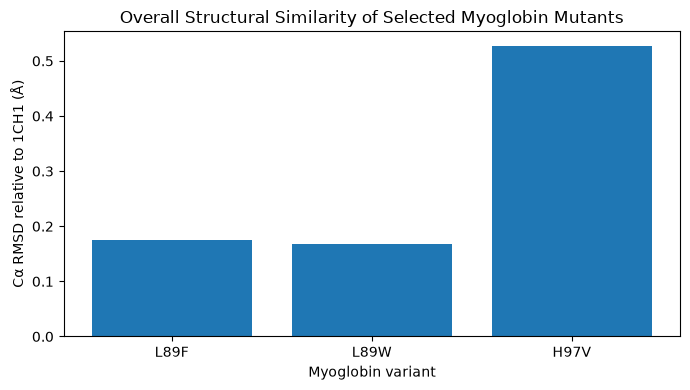

In [30]:
%matplotlib inline
plt.figure(
    figsize=(7, 4)
)

plt.bar(
    rmsd_results["mutation"],
    rmsd_results["rmsd_angstrom"]
)

plt.xlabel(
    "Myoglobin variant"
)

plt.ylabel(
    "Cα RMSD relative to 1CH1 (Å)"
)

plt.title(
    "Overall Structural Similarity of "
    "Selected Myoglobin Mutants"
)

plt.tight_layout()
plt.show()

In [31]:
rmsd_matrix = pd.DataFrame(
    index=pdb_ids,
    columns=pdb_ids,
    dtype=float
)


for pdb_a in pdb_ids:

    for pdb_b in pdb_ids:

        if pdb_a == pdb_b:

            rmsd_matrix.loc[
                pdb_a,
                pdb_b
            ] = 0.0

        else:

            result = calculate_ca_rmsd(
                parsed_structures[pdb_a],
                parsed_structures[pdb_b]
            )

            rmsd_matrix.loc[
                pdb_a,
                pdb_b
            ] = result["rmsd"]


rmsd_matrix.round(3)

,1CH1,1CH2,1CH3,1CH5
1CH1,0.000,0.175,0.167,0.527
1CH2,0.175,0.000,0.124,0.470
1CH3,0.167,0.124,0.000,0.484
1CH5,0.527,0.470,0.484,0.000


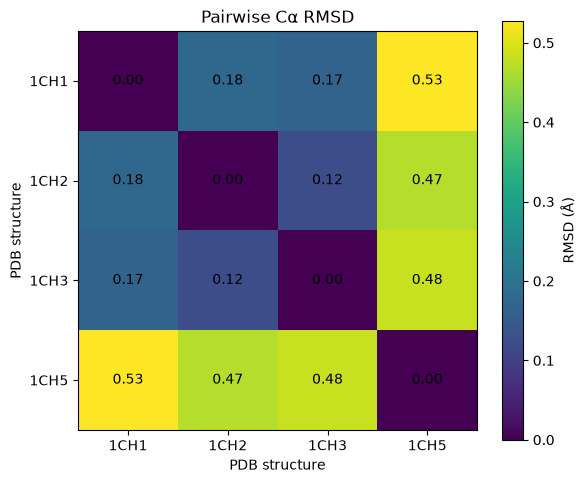

In [32]:
# Visualizes the pairwise RMSD matrix as a heatmap to show which myoglobin structures are most structurally similar.

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    rmsd_matrix.values
)

ax.set_xticks(
    range(len(pdb_ids))
)

ax.set_yticks(
    range(len(pdb_ids))
)

ax.set_xticklabels(
    pdb_ids
)

ax.set_yticklabels(
    pdb_ids
)

ax.set_xlabel(
    "PDB structure"
)

ax.set_ylabel(
    "PDB structure"
)

ax.set_title(
    "Pairwise Cα RMSD"
)

for i in range(len(pdb_ids)):

    for j in range(len(pdb_ids)):

        ax.text(
            j,
            i,
            f"{rmsd_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )


plt.colorbar(
    image,
    label="RMSD (Å)"
)

plt.tight_layout()
plt.show()

## 6. Interactive 3D Visualization

Numerical RMSD values summarize overall structural similarity, but protein
structures are inherently three-dimensional.

The retrieved mmCIF coordinate files can therefore be passed directly to an
interactive molecular viewer.

In [33]:
# Creates an interactive 3D molecular visualization of the 1CH1 myoglobin structure with the heme group highlighted.

pdb_id = "1CH1"

viewer = py3Dmol.view(
    width=800,
    height=500
)

viewer.addModel(
    structure_files[pdb_id].read_text(),
    "cif"
)

viewer.setStyle(
    {
        "protein": True
    },
    {
        "cartoon": {}
    }
)

viewer.setStyle(
    {
        "resn": "HEM"
    },
    {
        "stick": {}
    }
)

viewer.zoomTo()

viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [34]:
# Generates interactive 3D molecular visualizations for all four myoglobin variants for side-by-side structural inspection.

for pdb_id in pdb_ids:

    mutation = selected_structures.loc[
        selected_structures["pdb_id"]
        == pdb_id,
        "mutation"
    ].iloc[0]

    print(
        f"{pdb_id} — {mutation}"
    )

    viewer = py3Dmol.view(
        width=650,
        height=400
    )

    viewer.addModel(
        structure_files[pdb_id].read_text(),
        "cif"
    )

    viewer.setStyle(
        {"protein": True},
        {"cartoon": {}}
    )

    viewer.setStyle(
        {"resn": "HEM"},
        {"stick": {}}
    )

    viewer.zoomTo()

    viewer.show()

1CH1 — L89G


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

1CH2 — L89F


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

1CH3 — L89W


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

1CH5 — H97V


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 7. Interpretation

The selected structures represent closely related recombinant sperm whale
myoglobin variants.

The structural comparison asks whether the proteins retain a similar global
backbone architecture despite substitutions at selected amino-acid positions.

The pairwise Cα RMSD values quantify overall structural similarity, while the
interactive molecular views provide a qualitative view of the protein fold and
heme-containing structure.

The results should be interpreted as a demonstration of structural-data
retrieval and comparison rather than as evidence for the biological
consequences of the mutations. More detailed conclusions would require local
analysis around the mutation sites, comparison of side-chain interactions,
heme geometry, crystallographic resolution, and experimental conditions.

## 8. Role of DSI in the Workflow

This notebook separates **scientific data access** from **scientific analysis**.

### Without the DSI backend

A researcher would need to independently locate each PDB entry, inspect its
metadata, determine which structural files are available, retrieve those files,
and organize the information before beginning analysis.

### With the DSI RCSBPDB backend

The workflow becomes:

**PDB identifiers → DSI RCSBPDB → normalized datasets/resources →
coordinate files → structural analysis**

DSI does not replace specialized structural-biology software. Instead, the
RCSBPDB backend provides a consistent repository-access layer that allows PDB
data to participate in the same DSI-oriented workflow as other scientific data
repositories.

In this demonstration:

- the **datasets** table describes each PDB structure,
- the **resources** table exposes downloadable structural files,
- the **errors** table records unsuccessful resolutions,
- BioPython performs the downstream structural analysis, and
- py3Dmol provides interactive molecular visualization.

## Conclusion

This demonstration follows a complete path from a scientific question to a
small structural analysis using the DSI RCSBPDB backend.

Four related sperm whale myoglobin variants were retrieved through a single DSI
workflow. DSI exposed normalized PDB metadata and downloadable coordinate
resources, which were then used for downstream structural analysis.

The demonstration shows three stages of scientific data use:

1. **Access** — retrieve related PDB records through DSI.
2. **Organize** — examine normalized dataset and resource metadata.
3. **Analyze** — use the retrieved coordinate files for structural comparison
   and visualization.

The same pattern can be extended to larger collections of protein structures,
including conformational variants, protein-ligand complexes, and other
structure families available through RCSB PDB.